Accuracy: 0.8666666666666667

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.80      0.77       300
           1       0.94      0.87      0.90       300
           2       0.98      0.97      0.97       300
           3       0.82      0.83      0.83       300

    accuracy                           0.87      1200
   macro avg       0.87      0.87      0.87      1200
weighted avg       0.87      0.87      0.87      1200



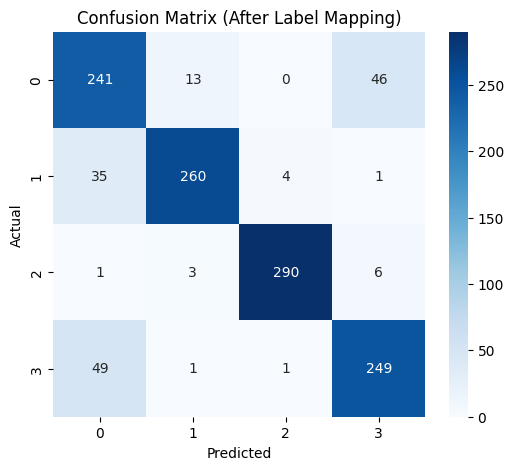

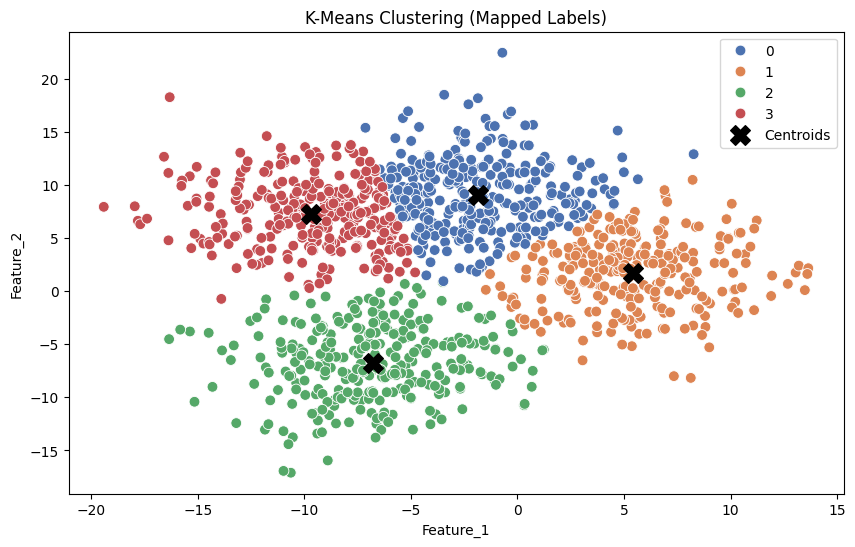

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from scipy.optimize import linear_sum_assignment

# -----------------------------
# 1. Generate dataset
# -----------------------------
X, y_true = make_blobs(
    n_samples=1200,
    centers=4,
    cluster_std=3.5,
    random_state=42
)

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

# -----------------------------
# 2. K-Means from scratch
# -----------------------------
class KMeansScratch:
    def __init__(self, k=4, max_iters=100):
        self.k = k
        self.max_iters = max_iters

    def fit(self, X):
        np.random.seed(42)
        random_indices = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[random_indices]

        for _ in range(self.max_iters):
            self.labels = self._assign_clusters(X)
            new_centroids = self._compute_centroids(X)

            if np.allclose(self.centroids, new_centroids):
                break

            self.centroids = new_centroids

    def _assign_clusters(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def _compute_centroids(self, X):
        return np.array([
            X[self.labels == i].mean(axis=0) for i in range(self.k)
        ])

# -----------------------------
# 3. Train model
# -----------------------------
kmeans = KMeansScratch(k=4)
kmeans.fit(X)

y_pred = kmeans.labels
df['Cluster'] = y_pred

# -----------------------------
# 4. Map cluster labels to true labels
# -----------------------------
def map_labels(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_ind, col_ind = linear_sum_assignment(-cm)

    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    mapped_labels = np.array([mapping[label] for label in y_pred])

    return mapped_labels

y_mapped = map_labels(y_true, y_pred)

# -----------------------------
# 5. Evaluation Metrics
# -----------------------------
print("Accuracy:", accuracy_score(y_true, y_mapped))
print("\nClassification Report:\n")
print(classification_report(y_true, y_mapped))

# Confusion Matrix
cm = confusion_matrix(y_true, y_mapped)

# -----------------------------
# 6. Confusion Matrix Visualization
# -----------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (After Label Mapping)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# 7. Cluster Visualization
# -----------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Feature_1',
    y='Feature_2',
    hue=y_mapped,
    palette='deep',
    data=df,
    s=60
)

centroids = kmeans.centroids
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='black',
    s=200,
    marker='X',
    label='Centroids'
)

plt.title("K-Means Clustering (Mapped Labels)")
plt.legend()
plt.show()

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   x        5000 non-null   float64
 1   y        5000 non-null   float64
 2   cluster  5000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 117.3 KB
